# Day 10 In-class Assignment

---


### <p style="text-align: right;"> &#9989; Put your name here</p>

#### <p style="text-align: right;"> &#9989; Put names of your group members</p>

## D is for dictionaries and dinosaurs

<img src="https://www.smbc-comics.com/comics/20090602.gif" style="display:block; margin-left: auto; margin-right: auto; width: 45%" alt="Save yourself mammal! We will fend off the asteroids! Caption: Paleontology texts have changed a lot since dinosaurs took over the school board.">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://smbc-comics.com/index.php?db=comics&id=1535" target="_blank">smbc-comics.com</a></p>

### Learning goals for today's assignment

* Practice storing data into dictionaries and looping through it
* Load data using NumPy so that you can visualize it using matplotlib
* Work with NumPy "array" objects to compute simple statistics using built-in NumPy functions.
* Use NumPy and matplotlib to look for correlation in data

### Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the Notebook. The assignment is due at the end of class.

---

## Background: Allometry, revisited

In this Notebook we will keep exploring the power of allometry (pun not intended). In the last assignment, we set to model body weight based solely on femur's circumference based on an *allometric* relationship:

#### $$\log_{10}(\text{Body Mass}) = b\times\log_{10}(\text{femur circumference}) + \log_{10}(a),$$

for some constant values $a, b$. If you recall from College Algebra, the formula above corresponds to a line.

<img src="https://media.springernature.com/full/springer-static/image/art%3A10.1186%2F1741-7007-10-60/MediaObjects/12915_2012_Article_575_Fig4_HTML.jpg?as=webp" style="display:block; margin-left: auto; margin-right: auto; width: 80%" alt="Raw OLS regression for body mass estimation and percent prediction error of body mass proxies">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://doi.org/10.1186/1741-7007-10-60" target="_blank">Campione and Evans (2012)</a></p>



&#9989;&nbsp; **Question: Only looking at Figure A**

- What information can you extract from the graph above?
- Do you think it is sensible to assume $\log_{10}$(Body Mass) and $\log_{10}$(Femur Circumference) follow a linear relationship, like the formula above suggests?
- How can we use the above information to predict the body mass of dinosaurs?

<font size="+3">&#9998;</font> *Put your response here*

---

## 1. Load tigers and hamsters with NumPy and dictionaries

In [1]:
# Although there are some exceptions, it is generally a good idea to keep all of your
# imports in one place so that you can easily manage them. Doing so also makes it easy
# to copy all of them at once and paste them into a new notebook you are starting.

# Bring in NumPy and Matplotlib
import numpy as np
import matplotlib.pyplot as plt

To use this notebook for your in-class assignment, you will need these files:

- `bovidae.csv` (buffalo-like)
- `canidae.csv` (dog-like)
- `cricetidae.csv` (hamster-like)
- `felidae.csv` (cat-like)
- `mustelidae.csv` (badger-like)
- `sciuridae.csv` (squirrel-like)

In the pre-class you already saw a small sample of this kind of data: each file has some animals of the same family and measurements related to their body mass (in grams), and femur bones (in mm). 

* Take a moment to look at the contents of these files with an editor on your computer.  For example, `*.csv` files open with Excel or, even better, look at it with a simple text editor like NotePad or TextEdit or just try opening it inside your Jupyter Notebook interface.

As you saw in the pre-class assignment, you can use the command below to load in the body mass and femur circumference data.

In [2]:
# use NumPy to read data from a csv file
# second, better example of loadtxt()
family = 'bovidae'
buff_mass, buff_femur = np.loadtxt(family + '.csv', usecols = [1,5], unpack=True, delimiter=',', skiprows=1)

Once you have your data, it is always a good idea to look at some of it to be sure it is what you think it is. You could use a print statement, or just type the variable name in an empty cell.

In [3]:
buff_femur

array([ 69.  ,  67.25,  47.55, 167.5 , 122.  , 156.5 ,  58.95,  88.  ,
        52.65,  87.  , 100.  ,  57.8 ,  92.5 , 111.  ,  79.  ,  81.5 ,
        46.  ,  97.  ,  62.  , 135.  ])

&#9989;&nbsp; **Question 1**

What do you think this data represents?

<font color="green" size="+3">&#9998;</font> *Put your answer here*

### 1.1 Using dictionaries

|Container Type|Mutable or Immutable|Initialization *Without* Values|Initializtion *With* Values|Adding Values to Container|Removing Values from Container|Modifying Values|Access Method        |Notable Operations and Additional Information|
|:----------|:----------|:----------|:----------|:----------|:----------|:----------|:----------|:----------|
|**Dictionary** $\hspace{0.5in}$| Mutable $\hspace{0.5in}$|<ul><li>`d=dict()`</li><li>`d={}`</li></ul> $\hspace{1.0in}$| `d={'Hordeum':'vulgare'}` $\hspace{1.5in}$|  <ul><li>`d['Juglans'] = 'regia' #Adds a new entry` </li></ul> $\hspace{2.5in}$|`del d['Hordeum'] #removes the entry related to Horedeum. If there is not such an element, this will cause an error` $\hspace{2.0in}$|`d['Juglans'] = 'nigra' # Now we get 'Juglans' associated to species 'nigra' instead of 'regia'` $\hspace{1.5in}$|Access by key: <br> `d['Hordeum'] # if there is no key named 'Hordeum', it will cause an error` <br> `1` $\hspace{1.2in}$|See webpage at [here](https://docs.python.org/3/library/stdtypes.html#dict) for some helpful methods when dealing with dictionaries. $\hspace{1.5in}$|

Now we need to load the data for the other five families. You could copy/paste and edit the `loadtxt` function above five more times. But this would mean a lot of copy/paste down the road if you want to compute statistics or make plots. Instead, we will load the data as entries of two large dictionaries. 

&#9989;&nbsp; **Task 2**

Below is a list `families` with the names of the six families to be analyzed. Note that the strings in this list match the filenames of the databases for today. Except they are missing the `.csv` extension.

- Initialize an empty `mass` dictionary where you'll eventually put mass data.
- Initialize an empty `femur` dictionary where you'll eventually put femur data.
- Loop through the `families` list
    - Inside the loop, load the mass and femur values from the CSV of the corresponding family.
    - You might need to add the `.csv` extension to the string. How do you concatenate strings?
    - Add the mass data in the `mass` dictionary. Use the family name (from `families`) as its key.
    - Same for the `femur` dictionary

The `femur` dictionary should look like
```
{'bovidae': array([ 69.  ,  67.25,  47.55, 167.5 , 122.  , 156.5 ,  58.95,  88.  ,
         52.65,  87.  , 100.  ,  57.8 ,  92.5 , 111.  ,  79.  ,  81.5 ,
         46.  ,  97.  ,  62.  , 135.  ]),
 'canidae': array([24.85, 40.6 , 51.75, 44.15, 25.75, 27.15, 23.3 , 26.95, 16.25]),
 'cricetidae': array([ 7.15,  8.  ,  5.6 ,  8.2 , 11.  ,  5.6 ,  5.7 ,  6.75, 11.8 ,
        11.05,  8.  ,  9.85,  7.5 ,  7.  , 10.  , 10.  ]),
 'felidae': array([ 67.5 ,  30.  ,  42.  ,  40.85,  39.  ,  38.25,  41.4 , 109.  ,
         72.5 ,  61.  , 102.5 ,  90.5 ,  63.  ,  62.5 ]),
 'mustelidae': array([29.3 , 35.  , 24.4 , 24.5 , 22.05,  7.7 , 10.2 , 13.05, 12.5 ,
        14.7 , 27.75]),
 'sciuridae': array([13.5 , 10.25, 25.1 , 22.  , 14.6 , 18.25, 10.05, 12.  ,  8.7 ,
        10.9 ,  8.8 ,  6.  ,  5.95,  9.95])}
```

In [4]:
# Read in data from the remaining files.
# Store the values in two dictionaries---mass and femur
# The dictionary keys help us keep track of which data is from which family

families = ['bovidae', 'canidae', 'cricetidae', 'felidae', 'mustelidae', 'sciuridae']

&#9989;&nbsp; **Question 3** 

- Before you move on, what is the variable type of the `femur` variable you've just made?
- What about of `femur['bovidae']`?

Use the `type()` function to check. Does this match your expectations?

<font color="green" size="+3">&#9998;</font> *Put your answer here*

___

## Part 2: Descriptive statistics of data sets

Now that you have read in the data, use NumPy's [statistics operations](https://numpy.org/doc/stable/reference/routines.statistics.html) from the pre-class to compare various properties of the body masses of the extant quadrupeds.

* mean
* median
* standard deviation

### **2.1 Means and Medians**

**What is the mean of a data set?**

The **mean**, also referred to as the average&ndash;represented by the Greek letter *mu* ($\mu$)&ndash;is calculated by adding up all of the observations in a data set, and dividing by the number of observations in the data set.

$$\mu = \frac1N\sum\limits_{i=1}^{N} x_i = \frac{\text{sum of observations}}{\text{number of observations}},$$ 

The mean of a data set is useful because it provides a single number to describe a dataset that can be very large. However, **the mean is sensitive to outliers (observations that are far from the mean)**, so it is best suited for data sets where the observations are close together.

**What is the median of a data set?**

The **median** of a data set is the middle value of a data set, or the value that divides the data set into two halves. The median also requires the data to be sorted from least to greatest. If the number of observations is odd, then the median is the middle value of the data set. If the number of observations is even, then the median is the average of the two middle numbers.

Unlike the mean, because the median is the midpoint of a data set, it is not strongly affected by a small number of outliers. 

### 2.2 Using NumPy to Calculate Mean and Median

We can write a function to calculate the mean and median ourselves, but NumPy already did that work for us! The [documentation](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) for `np.mean` shows additional options, but the basic use is: 

```python
np.mean(data)
```

Similarly, the median is calculated by:

```python
np.median(data)
```
&#9989;&nbsp; **Task 4** 

- In the cell below, calculate and print the mean and median of the body mass for each of the animal families, alongside the family name.
- Because all our data is in a dictionary with keys in `families`, we can simply loop through the `families` list to access the mass data for each animal family.

Remember masses are in grams. Do the means and medians make intuitive sense?

In [5]:
# Put your code here

### 2.3 Calculating Standard Deviation

One way to describe how "spread out" a data set is, we look at its **standard deviation**&mdash;often represented with the Greek letter sigma ($\sigma$).

$$\sigma = \sqrt{\frac1{N-1}\sum\limits_{i=1}^{N} (x_{i}-\mu)^2},$$

where the symbols in this equation represent the following:

* $\sigma$: Standard Deviation
* $\mu$: Mean
* $N$: Number of observations
* $x_{i}$: the value of dataset at position $i$

**Note:** In most of the textbooks you'll find $\frac1N$ instead of $\frac1{N-1}$. Doing $N-1$ corrects the sampling bias. This is known as the [Bessel's correction](https://en.wikipedia.org/wiki/Bessel%27s_correction). We'll discuss more about it later in the semester.

Similarly to `np.mean()` and `np.median()`, we can calculate the standard deviation with NumPy:

```python
# The ddof argument forces NumPy to divide 1/N-1 instead of 1/N
np.std(data, ddof=1)
```

&#9989;&nbsp; **Task 5** 

- In the cell below, calculate and print the standard deviation of body mass for each of the families. Use code similar to Task 4.
- Which family reports the largest SD? The smallest? Which family/families have an SD larger than its mean?

Are there any results you find surprising?

In [6]:
# put your code here

### 2.4 Visualizing the Data with matplotlib

Let's have a better idea of what's in the files. 

&#9989;&nbsp; **Task 6** 

For the Bovidae family:

- Compute the log (base 10) of the body mass and the femur circumference
     - If you store these log values in a variable prior to plotting them, make sure they are in another dictionary.
- Do a *scatterplot* of log body mass versus log bone circumference using `matplotlib`.
- This means that log body mass should go on the **y-axis** and log bone circumference should go on the **x-axis**.

This is our first example of doing some (very simple!) data science - looking at some real data. As a reminder, the data came from an [actual research paper](https://link.springer.com/article/10.1186/1741-7007-10-60). If you ever find data like this in the real world, you could build a Notebook like this one to examine it. In fact, your projects at the end of the semester might be much larger versions of this. 

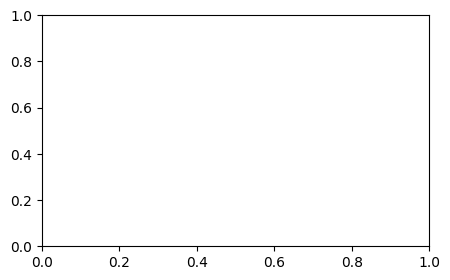

In [7]:
# Do a scatterplot mass vs femur circumference here
fig, ax = plt.subplots(figsize=(5,3))

Without labels, plots are not very useful. If you showed them to someone else they would have no idea what is in them. In fact, if *you* looked at them next week, you wouldn't remember what is in them. Let's use a little more `matplotlib` to make them of professional quality. 

There are two things that every plot should have: labels on each axis. And, there are many other options:

* [`grid`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.grid.html)
* [`set_title`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_title.html)
* [`markers`](https://matplotlib.org/examples/lines_bars_and_markers/marker_reference.html)
* [`legend`](https://matplotlib.org/users/legend_guide.html)
* and many more we will see over time...

&#9989;&nbsp; **Task 7**

- Remake separate figures for each of the datasets you read in and include in the plots: $x$-axis labels, $y$-axis labels, grid lines, markers, and a title.
- Make all of them in the *same* plot using the same formating techniques you used in the separate plots but also *add a legend*.
- Give each family a different color and marker using the `colors` and `markers` lists.
- You might want to have `edgecolor='black'` as part of your `ax.plot` arguments to give each marker a black contour.
- *Hint*: Remember your work from Pre-Class 09 and that we can loop with indices.

If you find yourself waiting for help from an instructor, you can also try using duckduckgo to answer your questions. Searching the internet for coding tips and tricks is a very common practice!

The Python community also provides helpful resources: they have created a comprehensive gallery of just about any plot you can think of with an example *and the code that goes with it*. That gallery is [here](https://matplotlib.org/gallery.html) and you should be able to find many examples of how to make your plots look professional. (You just might want to bookmark that webpage...)

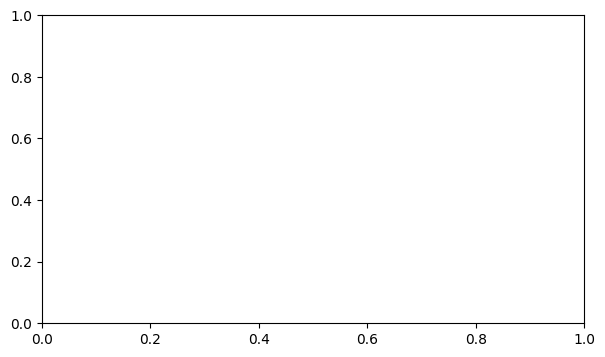

In [8]:
# Make another plot here with all the data in the same plot and include a legend

colors = ['r', 'yellow', 'dodgerblue', 'orange', 'gray', 'cyan']
markers = ['o', '^', 'v', 's', 'D', 'p']
fig, ax = plt.subplots(figsize=(7,4))

&#9989;&nbsp; **Question 8**

- What observations about the data do you have?
- Does it look like the log observations follow a line?
- What do you think of the fact that both hamsters and buffalos seem to follow the same trend despite huge size differences?

<font color="green" size="+3">&#9998;</font> In the data I see....

___

## Part 3: Looking for correlations in data (Time Permitting)

In the plot above (and in the original paper) you probably observed that log body mass and log bone circumference follow a nice linear pattern. This suggests that both measurements are *correlated*.

We are going to explore how to **quantify** these correlations. There are many ways to measure correlation, but we are going to use the **Pearson Correlation Coefficient** (also referred to as "r", "rho",  "$\rho$", or "correlation coefficient"). The Pearson Correlation Coefficient ranges from -1 to 1 and provides a measure of how dependent on one another your variables are. 

If the correlation coefficient is close to 1 or -1, then the correlation is strong, if it is close to zero, the correlation is weak. If the the correlation coefficient is negative, then the y values decrease as x increases. If the correlation coefficient is positive, then the y values increase as x increases. See the image below for a visualization of this!

<img src="https://upload.wikimedia.org/wikipedia/commons/d/d4/Correlation_examples2.svg" style="display:block; margin-left: auto; margin-right: auto; width: 80%" alt="Cartoon with correlation coefficient examples">
<p style="font-size:0.85em; text-align: center;">Credits: <a href="https://en.wikipedia.org/wiki/Pearson_correlation_coefficient" target="_blank">Wikipedia</a></p>

![Correlation Coeficient Examples]().

### 3.1 Using `np.corrcoef()`

To calculate the correlation coefficient, we are going to use another NumPy function, [np.corrcoef](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html). For two measurments `x` and `y`, you can use it like
```python
np.corrcoef(x,y)
```

It will return all of the possible correlation coefficients (including the data with itself) as an array.

&#9989;&nbsp; **Task 9** 

- Pick two families of your choice.
- In the cell below, calculate the correlation coefficient between log body mass and the log femur circumferences for these two families.

Were there any differences between your qualitative observations and your quantitative calculations?

In [9]:
# put your code here


<font size="+3" color="green">&#9998;</font> I observed.....

In [10]:
## 

___

## ASIDE: Saving Plots

Finally, you will need to use your plots for something. In your other classes and labs you often will need to make plots for your assignments and lab reports - now is the time to start using Python for that! Modify the code above to write the plot into a file in PNG format. You just need to add the following lines at the end of the cell where you make plots. Here are a couple of examples for how you can save files as a PNG file:

```python
fig.savefig('my_plot.png', dpi=150, bbox_inches='tight')
# You can also have .jpg, .pdf, or .svg files
# Increase or decrease dpi for better or worse resolution
```

**Put your name in the filename** so that we can keep track of your work.

---

### Congratulations, you're done!

Submit this assignment by uploading it to the course Canvas web page.  Go to the "Pre-class assignments" folder, find the appropriate submission folder link, and upload it there.

See you in class!

&#169; Copyright 2026,  Division of Plant Science & Technology&mdash;University of Missouri